# Code for Figure S8

Per-plate (leave-one-plate-out) performance scores and training-init seed stability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

# one consistent font scheme for all S8 panels; 200 dpi for sharp (non-blurry) inline figures
plt.rcParams.update({'axes.titlesize': 9, 'axes.labelsize': 8,
                     'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 6.5,
                     'figure.dpi': 200, 'savefig.dpi': 200})

OVR = '#d62728'  # overall (pooled-across-plates) marker colour


# balanced accuracy = mean per-class recall from a COUNT confusion matrix (as in the other figure notebooks)
def cm_metrics(mat):
    C = np.nan_to_num(np.asarray(mat.reindex(columns=list(mat.index)), dtype=float))
    tp = np.diag(C); row = C.sum(1); col = C.sum(0)
    with np.errstate(divide='ignore', invalid='ignore'):
        rec = np.where(row > 0, tp / row, np.nan)
        prec = np.where(col > 0, tp / col, np.nan)
        f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return np.nanmean(np.where(row > 0, f1, np.nan)), np.nanmean(rec)


def binary_conf(true_lab, pred_lab, classes=('H', 'C')):
    t = pd.Categorical(true_lab, categories=list(classes))
    p = pd.Categorical(pred_lab, categories=list(classes))
    return (pd.crosstab(t, p, dropna=False)
            .reindex(index=list(classes), columns=list(classes), fill_value=0))


def _compact(ax):  # bigger, tighter fonts for the compact H/C-style panels (S8a, S8c, S8d)
    ax.title.set_fontsize(10)
    ax.xaxis.label.set_size(11); ax.yaxis.label.set_size(11)
    ax.tick_params(labelsize=10)

## Per-fold scores

### Fig. S8a

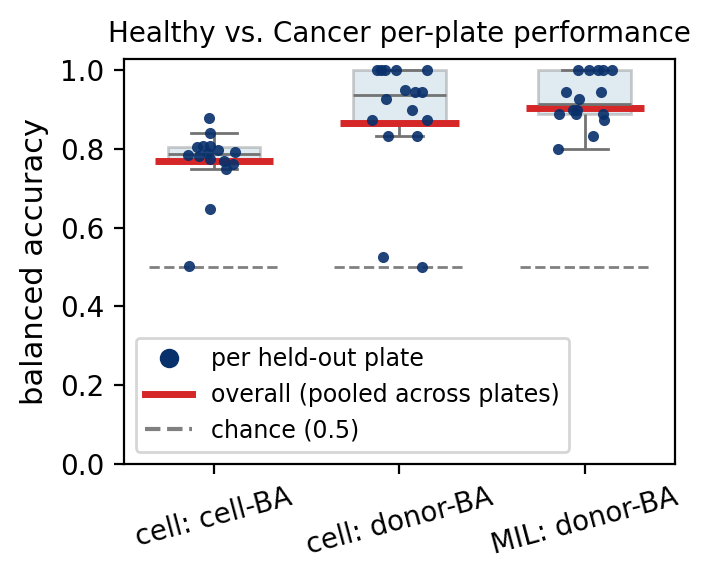

In [2]:
rows, overall = [], []

# cell-level Classifier at donor- and cell-level -- published models, Fig 2 100-cell test bags
cc = pd.read_csv('results/fig2_cell_hc_predictions.csv')  # fraction predicted healthy per (donor, plate)
cell = cc.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index().rename(columns={'pred': 'pred H %', 'pat': 'patient'})
cell['is_H'] = cell['group'] == 'healthy'
cell['true'] = np.where(cell['is_H'], 'H', 'C')

def cell_level_ba(sub):  # cell-level accuracy per donor, averaged by class (each donor an equal-size bag, as Fig 2)
    return 0.5 * (sub[sub['is_H']]['pred H %'].mean() + (1 - sub[~sub['is_H']]['pred H %']).mean())

for plate, g in cell.groupby('plate'):
    _, ba_d = cm_metrics(binary_conf(g['true'], np.where(g['pred H %'] >= 0.5, 'H', 'C')))  # donor majority vote
    rows.append(dict(task='cell: donor-BA', plate=plate, balanced_accuracy=ba_d))
    rows.append(dict(task='cell: cell-BA', plate=plate, balanced_accuracy=cell_level_ba(g)))
pv = cell.groupby(['patient', 'true'])['pred H %'].mean().reset_index()  # pooled: donor first across plates, then vote
_, ba_do = cm_metrics(binary_conf(pv['true'], np.where(pv['pred H %'] >= 0.5, 'H', 'C')))
overall += [dict(task='cell: donor-BA', overall_BA=ba_do), dict(task='cell: cell-BA', overall_BA=cell_level_ba(cell))]

# MIL healthy-vs-cancer (donor majority vote of bags)
hc = pd.read_csv('results/fig3_hc_mil_predictions.csv')
bag = hc.groupby(['plate', 'pat', 'i'])[['pred', 'lab', 'group']].max().reset_index()
for plate, g in bag.groupby('plate'):
    pat = g.groupby(['pat', 'group'])['pred'].agg(lambda x: x.mode(dropna=True)[0]).dropna().reset_index()
    _, ba = cm_metrics(binary_conf(np.where(pat['group'] == 'healthy', 'H', 'C'), np.where(pat['pred'] == 1, 'H', 'C')))
    rows.append(dict(task='MIL: donor-BA', plate=plate, balanced_accuracy=ba))
poolp = bag.groupby(['pat', 'group'])['pred'].agg(lambda x: x.mode(dropna=True)[0]).dropna().reset_index()
_, ba_o = cm_metrics(binary_conf(np.where(poolp['group'] == 'healthy', 'H', 'C'), np.where(poolp['pred'] == 1, 'H', 'C')))
overall.append(dict(task='MIL: donor-BA', overall_BA=ba_o))

metrics = pd.DataFrame(rows)
overall_df = pd.DataFrame(overall)

TASK_ORDER = ['cell: cell-BA', 'cell: donor-BA', 'MIL: donor-BA']
fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))
sns.boxplot(data=metrics, x='task', y='balanced_accuracy', order=TASK_ORDER, ax=ax,
            showfliers=False, width=0.5, boxprops=dict(alpha=0.35), color='#9ecae1')
sns.stripplot(data=metrics, x='task', y='balanced_accuracy', order=TASK_ORDER, ax=ax,
              color='#08306b', size=4, jitter=0.15, alpha=0.9, zorder=5)
for i, t in enumerate(TASK_ORDER):
    v = overall_df.loc[overall_df['task'] == t, 'overall_BA'].iloc[0]
    ax.hlines(v, i - 0.32, i + 0.32, colors=OVR, lw=2.5, zorder=2)
    ax.hlines(0.5, i - 0.35, i + 0.35, colors='grey', linestyles='--', lw=1)
ax.set_ylabel('balanced accuracy'); ax.set_xlabel(''); ax.set_ylim(0, 1.03)
ax.tick_params(axis='x', rotation=15)
handles = [mlines.Line2D([], [], color='#08306b', marker='o', ls='', label='per held-out plate'),
           mlines.Line2D([], [], color=OVR, ls='-', lw=2.5, label='overall (pooled across plates)'),
           mlines.Line2D([], [], color='grey', ls='--', label='chance (0.5)')]
ax.legend(handles=handles, loc='lower left', fontsize=8.5)
ax.set_title('Healthy vs. Cancer per-plate performance')
_compact(ax)
fig.tight_layout()

### Fig. S8b

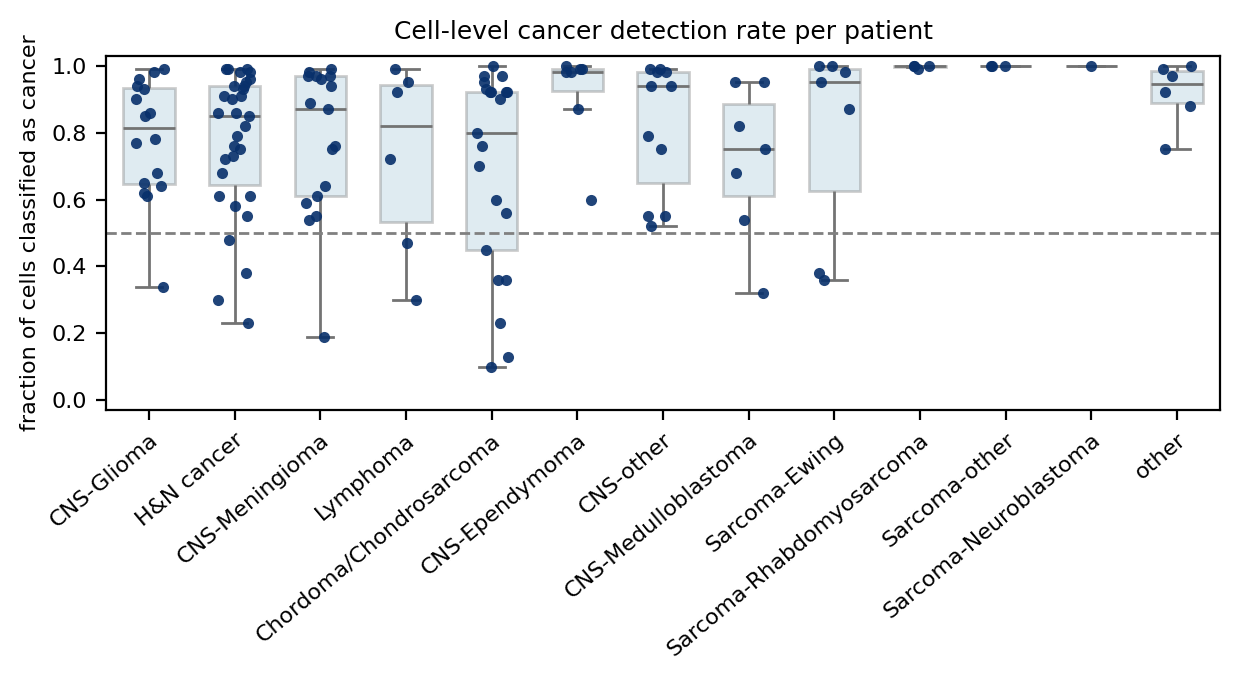

In [3]:
diag = pd.read_csv('meta/patient_diagnosis_groups.csv')  # patient, group
cc = pd.read_csv('results/fig2_cell_hc_predictions.csv')
cell_c = cc[cc['group'] == 'cancer'].groupby(['plate', 'pat'])['pred'].mean().reset_index().rename(columns={'pat': 'patient'})
cell_c['detect'] = 1 - cell_c['pred']  # fraction of the donor's cells predicted cancer
cell_c = cell_c.merge(diag, on='patient', how='left')
cell_c['group'] = cell_c['group'].fillna('other')

# cancer-type order as in figures_1_S1 cell 13; dots are a single colour since the x-axis already encodes type
TYPE_ORDER = ['CNS-Glioma', 'H&N cancer', 'CNS-Meningioma', 'Lymphoma', 'Chordoma/Chondrosarcoma',
              'CNS-Ependymoma', 'CNS-other', 'CNS-Medulloblastoma', 'Sarcoma-Ewing',
              'Sarcoma-Rhabdomyosarcoma', 'Sarcoma-other', 'Sarcoma-Neuroblastoma', 'other']

fig, ax = plt.subplots(1, 1, figsize=(6.3, 3.5))
sns.boxplot(data=cell_c, x='group', y='detect', order=TYPE_ORDER, ax=ax, showfliers=False,
            width=0.6, boxprops=dict(alpha=0.35), color='#9ecae1')
sns.stripplot(data=cell_c, x='group', y='detect', order=TYPE_ORDER, ax=ax,
              color='#08306b', size=4, jitter=0.2, alpha=0.9, zorder=5)
ax.axhline(0.5, color='grey', ls='--', lw=1)
ax.set_title('Cell-level cancer detection rate per patient')
ax.set_xlabel(''); ax.set_ylabel('fraction of cells classified as cancer')
ax.set_xticks(range(len(TYPE_ORDER)))
ax.set_xticklabels(TYPE_ORDER, rotation=40, ha='right', rotation_mode='anchor')
ax.set_ylim(-0.03, 1.03)
fig.tight_layout()

### Fig. S8c

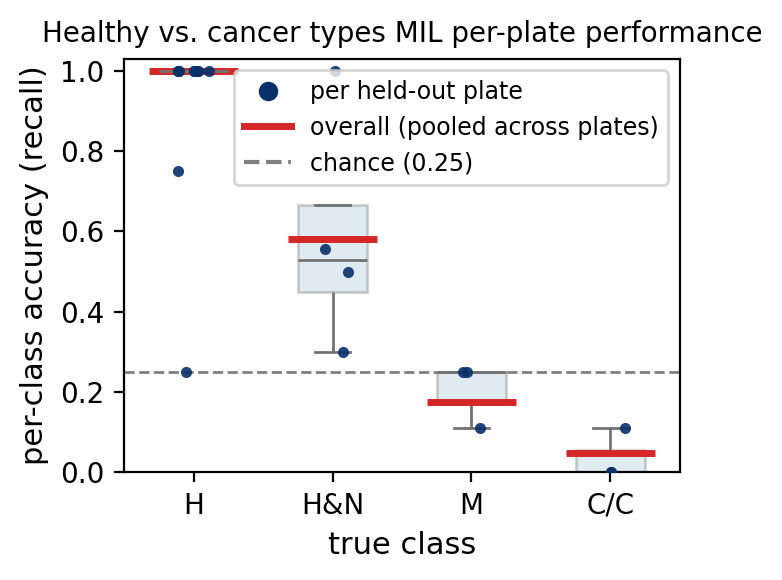

In [4]:
CLS4 = ['H', 'H&N', 'M', 'C/C']
GROUPS = ['healthy', 'H&N cancer', 'CNS-Meningioma', 'Chordoma/Chondrosarcoma']
SHORT = {'healthy': 'H', 'H&N cancer': 'H&N', 'CNS-Meningioma': 'M', 'Chordoma/Chondrosarcoma': 'C/C'}
gt = pd.read_csv('results/fig3_grouptype_mil_predictions.csv')
gbag = gt.groupby(['plate', 'pat', 'i'])[['pred', 'group']].max().reset_index()
gbag['pred'] = pd.Categorical(gbag['pred'].map(lambda x: GROUPS[x]).replace(SHORT), categories=CLS4)
gbag['group'] = pd.Categorical(gbag['group'].replace(SHORT), categories=CLS4)

def perclass_recall(df):  # donor majority vote, then recall per true class
    pat = df.groupby(['pat', 'group'], observed=False)['pred'].agg(lambda x: x.mode(dropna=True)[0]).dropna().reset_index()
    mat = (pat.groupby(['group', 'pred'], observed=False)['pat'].count()
           .reset_index().pivot(index='group', columns='pred', values='pat')
           .reindex(index=CLS4, columns=CLS4).fillna(0))
    tp = np.diag(mat.values); row = mat.values.sum(1)
    return {c: (tp[i] / row[i] if row[i] > 0 else np.nan) for i, c in enumerate(CLS4)}, row

pc_rows = []
for plate, g in gbag.groupby('plate'):
    rec, row = perclass_recall(g)
    for i, c in enumerate(CLS4):
        if row[i] > 0:  # only plates where the class is actually present
            pc_rows.append(dict(cls=c, plate=plate, recall=rec[c]))
fourway_perplate = pd.DataFrame(pc_rows)
rec_o, _ = perclass_recall(gbag)
fourway_overall = pd.DataFrame([dict(cls=c, recall=rec_o[c]) for c in CLS4])

fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))
sns.boxplot(data=fourway_perplate, x='cls', y='recall', order=CLS4, ax=ax,
            showfliers=False, width=0.5, boxprops=dict(alpha=0.35), color='#9ecae1')
sns.stripplot(data=fourway_perplate, x='cls', y='recall', order=CLS4, ax=ax,
              color='#08306b', size=4, jitter=0.12, alpha=0.9, zorder=5)
for i, c in enumerate(CLS4):
    v = fourway_overall.loc[fourway_overall['cls'] == c, 'recall'].iloc[0]
    ax.hlines(v, i - 0.32, i + 0.32, colors=OVR, lw=2.5, zorder=2)
ax.axhline(0.25, color='grey', ls='--', lw=1)
handles4 = [mlines.Line2D([], [], color='#08306b', marker='o', ls='', label='per held-out plate'),
            mlines.Line2D([], [], color=OVR, ls='-', lw=2.5, label='overall (pooled across plates)'),
            mlines.Line2D([], [], color='grey', ls='--', label='chance (0.25)')]
ax.legend(handles=handles4, loc='upper right', fontsize=8.5)
ax.set_ylabel('per-class accuracy (recall)'); ax.set_xlabel('true class'); ax.set_ylim(0, 1.03)
ax.set_title('Healthy vs. cancer types MIL per-plate performance')
_compact(ax)
fig.tight_layout()

## Training init seed stability

Re-training the two healthy-vs-cancer models across 10 training-init seeds barely moves the
result. Each dot is one seed's overall balanced accuracy (donor-level, pooled across plates);
the red marker is the value used in the other figures (the published leave-one-plate-out model).
Training and evaluation are in `notebooks/seed_stability_healthy_cancer.ipynb`; this panel only
reads the per-seed predictions it writes to `results/seed_stability/`.

Note that even with seeds fixed, GPU/PyTorch ops are not fully deterministic, so the exact
numbers vary slightly between runs — the takeaway is that the spread across seeds is small.

### Fig. S8d

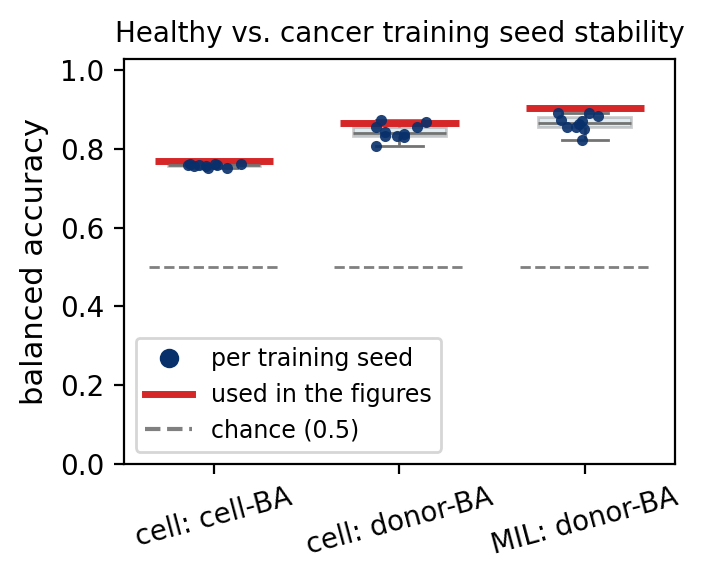

In [5]:
import glob
SS = 'results/seed_stability'

# cell-level per-seed: fraction predicted healthy per (donor, plate) -- analog of 'pred H %' in S8a
cellp = pd.concat([pd.read_csv(f) for f in glob.glob(f'{SS}/preds_cell_seed*_plate*.csv')], ignore_index=True)
cf = cellp.groupby(['seed', 'plate', 'pat', 'group'])['pred'].mean().reset_index().rename(columns={'pred': 'frac'})
cf['is_H'] = cf['group'] == 'healthy'

def cell_level_ba_seed(sub):  # same as S8a cell_level_ba, on this seed's rows
    return 0.5 * (sub[sub['is_H']]['frac'].mean() + (1 - sub[~sub['is_H']]['frac']).mean())

# MIL per-seed: bag-level vote
milp = pd.concat([pd.read_csv(f) for f in glob.glob(f'{SS}/preds_mil_seed*_plate*.csv')], ignore_index=True)
milbag = milp.groupby(['seed', 'plate', 'pat', 'group', 'i'])['pred'].max().reset_index()

seed_rows = []
for seed, g in cf.groupby('seed'):
    seed_rows.append(dict(task='cell: cell-BA', seed=seed, BA=cell_level_ba_seed(g)))          # cell-level accuracy
    dv = g.groupby(['pat', 'is_H'])['frac'].mean().reset_index()                                # donor first, pooled across plates
    _, ba = cm_metrics(binary_conf(np.where(dv['is_H'], 'H', 'C'), np.where(dv['frac'] >= 0.5, 'H', 'C')))
    seed_rows.append(dict(task='cell: donor-BA', seed=seed, BA=ba))
for seed, g in milbag.groupby('seed'):
    dv = g.groupby(['pat', 'group'])['pred'].agg(lambda x: x.mode(dropna=True)[0]).reset_index()
    _, ba = cm_metrics(binary_conf(np.where(dv['group'] == 'healthy', 'H', 'C'), np.where(dv['pred'] == 1, 'H', 'C')))
    seed_rows.append(dict(task='MIL: donor-BA', seed=seed, BA=ba))
seed_df = pd.DataFrame(seed_rows)

# red marker = value used in the other figures (published leave-one-plate-out model), from S8a
fig_ref = overall_df.set_index('task')['overall_BA']

order = ['cell: cell-BA', 'cell: donor-BA', 'MIL: donor-BA']  # same tasks as S8a
fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))
sns.boxplot(data=seed_df, x='task', y='BA', order=order, ax=ax, showfliers=False,
            width=0.5, boxprops=dict(alpha=0.35), color='#9ecae1')
sns.stripplot(data=seed_df, x='task', y='BA', order=order, ax=ax, color='#08306b', size=4, jitter=0.15, alpha=0.9, zorder=5)
for i, t in enumerate(order):
    ax.hlines(fig_ref[t], i - 0.32, i + 0.32, colors=OVR, lw=2.5, zorder=2)
    ax.hlines(0.5, i - 0.35, i + 0.35, colors='grey', linestyles='--', lw=1)
ax.set_ylabel('balanced accuracy'); ax.set_xlabel(''); ax.set_ylim(0, 1.03)
ax.tick_params(axis='x', rotation=15)
handles_d = [mlines.Line2D([], [], color='#08306b', marker='o', ls='', label='per training seed'),
             mlines.Line2D([], [], color=OVR, ls='-', lw=2.5, label='used in the figures'),
             mlines.Line2D([], [], color='grey', ls='--', label='chance (0.5)')]
ax.legend(handles=handles_d, loc='lower left', fontsize=8.5)
ax.set_title('Healthy vs. cancer training seed stability')
_compact(ax)
fig.tight_layout()